In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score





class MalariaML:

    def __init__(self, file_path):
        print("Loading dataset.....")
        self.file_path = file_path
        self.df = pd.read_csv(file_path)
        self.target = None
        print("Dataset loaded successfully\n")


    
    #View Dataset
    def explore_data(self):
        print("First 5 rows:")
        print(self.df.head())
        print("\n Info:")
        print(self.df.info())
        print("\n Missing values:")
        print(self.df.isnull().sum())
    


    #Cleaning 
    def clean_data(self):
        print("\n Cleaning data...")

        #Drop duplicates
        self.df = self.df.drop_duplicates()

        #fill missing values
        self.df = self.df.fillna(method="ffill").fillna(method="bfill")
        print('Cleaning done\n')

    
    def handle_columns(self):
        self.df.columns = (self.df.columns.astype(str)
                .str.lower()
                .str.strip()
                .str.replace(" ", "_", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace("%", "", regex=False)
                )

        
        self.df = self.df.rename(columns={
        'country_name': 'country',
        'year': 'year',
        'country_code': 'country_code',
        'incidence_of_malaria_per_1,000_population_at_risk': 'incidence_per_1000',
       'malaria_cases_reported':  'malaria_cases_reported' ,
       'use_of_insecticide-treated_bed_nets__of_under-5_population': 'use_of_insecticide_per_population',
       'children_with_fever_receiving_antimalarial_drugs__of_children_under_age_5_with_fever':  'children_with_under_age_5_fever',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy__of_pregnant_women': 'ipt_of_malaria_pregnant_women',
       'people_using_safely_managed_drinking_water_services__of_population': 'ppl_drinking_water_serv_pop',
       'people_using_safely_managed_drinking_water_services,_rural__of_rural_population': 'ppl_drinking_water_serv_rural_pop',
       'people_using_safely_managed_drinking_water_services,_urban__of_urban_population':  'ppl_drinking_water_serv_urban_pop',
       'people_using_safely_managed_sanitation_services__of_population': 'ppl_sanitation_services__of_population',
       'people_using_safely_managed_sanitation_services,_rural__of_rural_population': 'ppl_sanitation_services__of_rural_pop',
       'people_using_safely_managed_sanitation_services,_urban___of_urban_population': 'ppl_sanitation_services__of_urban_pop',
       'rural_population__of_total_population': "rural_tot_pop",
       'rural_population_growth_annual_': 'rural_pop_growth_ann',
       'urban_population__of_total_population': 'urban_tot_pop',
       'urban_population_growth_annual_': 'urban_pop_growth_ann',
       'people_using_at_least_basic_drinking_water_services__of_population': 'ppl_basic_drinking_water_pop' ,
       'people_using_at_least_basic_drinking_water_services,_rural__of_rural_population': 'ppl_basic_drinking_water_rural_pop' ,
       'people_using_at_least_basic_drinking_water_services,_urban__of_urban_population': 'ppl_basic_drinking_water_urban_pop',
       'people_using_at_least_basic_sanitation_services__of_population': 'ppl_using_basic_sanitation_pop',
       'people_using_at_least_basic_sanitation_services,_rural__of_rural_population': 'ppl_using_basic_sanit_rural_of_rural_pop',
       'people_using_at_least_basic_sanitation_services,_urban___of_urban_population': 'ppl_using_basic_sanit_urban_of_urban_pop',
       'latitude': 'latitude',
        'longitude': 'longitude',
        'geometry': 'geometry'
        })



        self.df.drop(columns=['country_code', 'year', 'country'])

        print("Handling and Column Dropping Done")

    def create_target(self):

        def calculate_risk(malaria_cases, bednet):
            return (1 if malaria_cases > 100000 and bednet < 50 else 0)
    
        self.df["malaria"] = self.df.apply(lambda r: calculate_risk(r['malaria_cases_reported'],
                                                                    r['use_of_insecticide_per_population']),
                                                                    axis=1
                                                                    )
    def visualise(self):
        print("Visualising......")

        self.df.hist(figsize=(10, 6))
        plt.tight_layout()
        plt.show()

    #Define Features and Targets
    def define_target(self):
        print("Defining target........")

        #We assume malaria column exists (adjust if needed)

        self.target = 'malaria'
        

        self.X = self.df.drop(columns=[self.target])
        self.y = self.df[self.target]

        print(f"Target column: {self.target}\n")
 

    #Preprocessing (VERY IMPORTANT)
    def preprocess(self):
        print(" Preprocessing......")

        #Separate numerical and categorical 
        self.num_cols = self.X.select_dtypes(include=['int64', 'float64']).columns
        self.cat_cols = self.X.select_dtypes(include=['object']).columns

        print("Numerical columns:", self.num_cols)
        print("Categorical columns:", self.cat_cols)


        #Transformers
        num_transformer = StandardScaler()
        cat_transformer = OneHotEncoder(handle_unknown='ignore')

        self.preprocessor = ColumnTransformer(transformers=[
            ('num', num_transformer, self.num_cols),
            ('cat', cat_transformer, self.cat_cols)
        ] )
    









In [3]:

import pandas as pd 

df = pd.read_csv("DatasetAfricaMalaria.csv")

df.columns = (df.columns.astype(str)
                .str.lower()
                .str.strip()
                .str.replace(" ", "_", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace("%", "", regex=False)
                
                )
                

In [4]:
df.columns

Index(['country_name', 'year', 'country_code',
       'incidence_of_malaria_per_1,000_population_at_risk',
       'malaria_cases_reported',
       'use_of_insecticide-treated_bed_nets__of_under-5_population',
       'children_with_fever_receiving_antimalarial_drugs__of_children_under_age_5_with_fever',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy__of_pregnant_women',
       'people_using_safely_managed_drinking_water_services__of_population',
       'people_using_safely_managed_drinking_water_services,_rural__of_rural_population',
       'people_using_safely_managed_drinking_water_services,_urban__of_urban_population',
       'people_using_safely_managed_sanitation_services__of_population',
       'people_using_safely_managed_sanitation_services,_rural__of_rural_population',
       'people_using_safely_managed_sanitation_services,_urban___of_urban_population',
       'rural_population__of_total_population',
       'rural_population_growth_annual_',
       'urba

In [8]:
df["malaria_cases_reported"].describe()

count    5.500000e+02
mean     1.068330e+06
std      2.192802e+06
min      0.000000e+00
25%      2.211750e+03
50%      1.130260e+05
75%      1.154808e+06
max      1.682113e+07
Name: malaria_cases_reported, dtype: float64

In [14]:
df.shape

(594, 27)

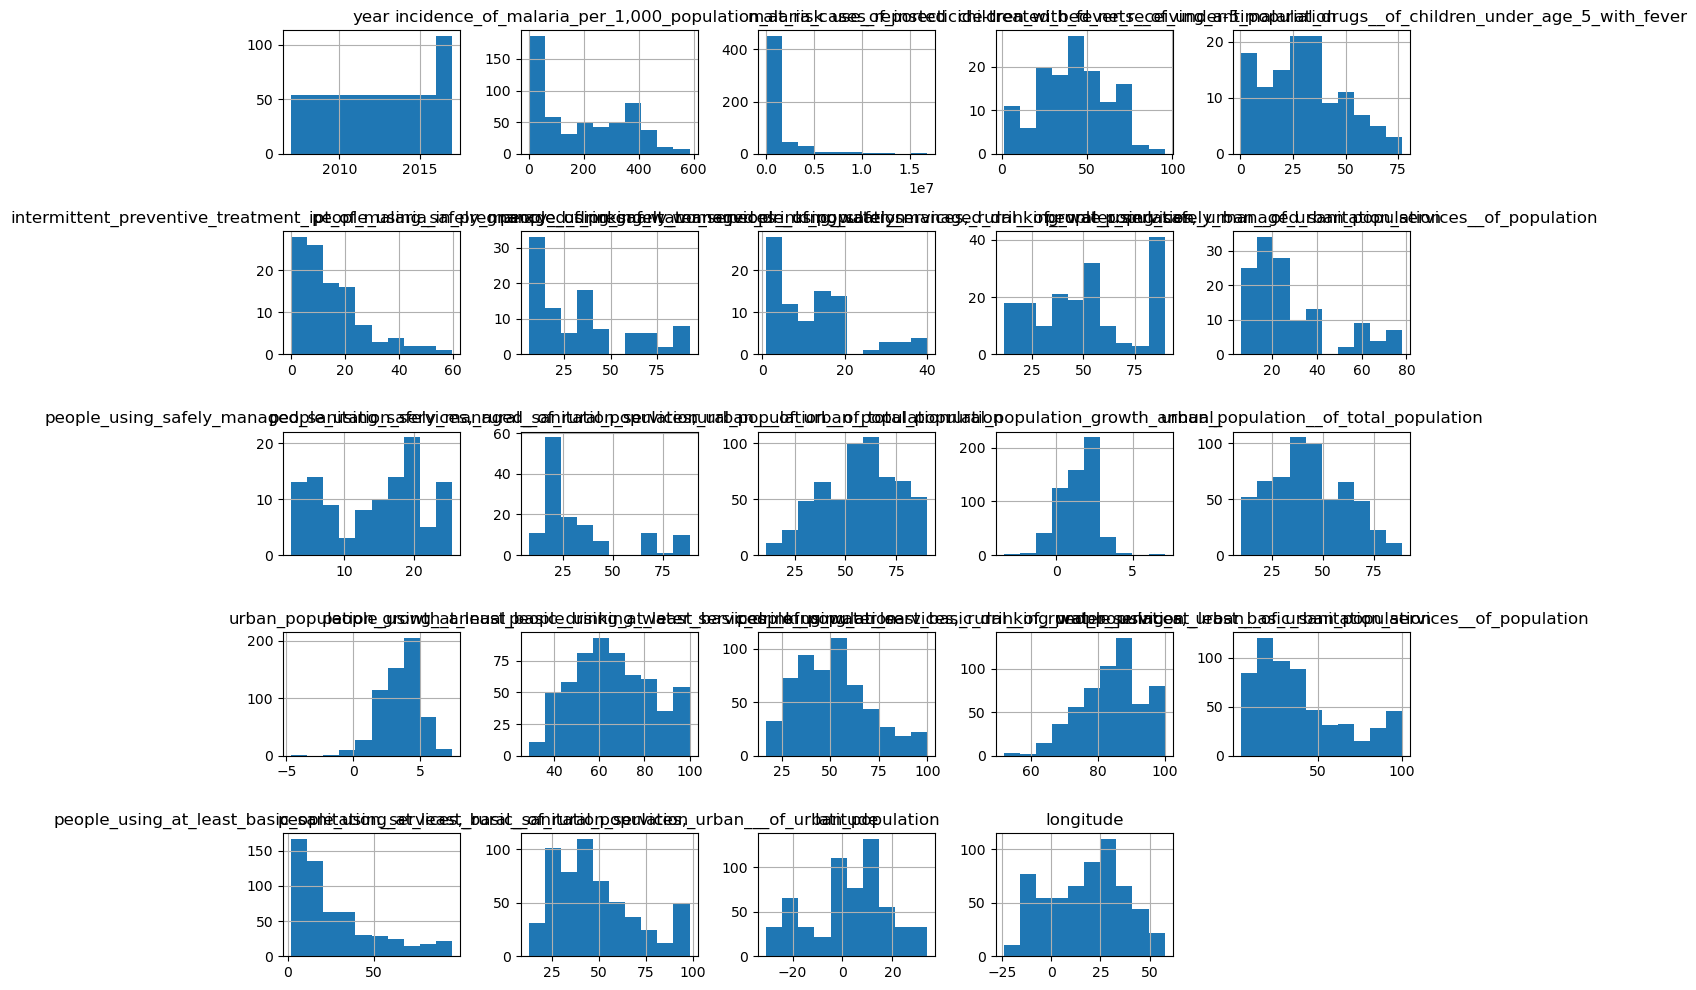

In [13]:
import matplotlib.pyplot as plt 

df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()
